first best

Nombre de caractéristiques sélectionnées : 22
Caractéristiques sélectionnées : ['Jitter_rel', 'Jitter_abs', 'Jitter_RAP', 'Jitter_PPQ', 'Shim_loc', 'Shim_dB', 'Shim_APQ3', 'Shi_APQ11', 'HNR15', 'HNR25', 'HNR35', 'HNR38', 'RPDE', 'PPE', 'MFCC1', 'MFCC2', 'MFCC5', 'Delta0', 'Delta1', 'Delta4', 'Delta9', 'Delta10']

 Validation croisée pour le modèle : Naïve Bayes
              precision    recall  f1-score   support

           0      0.741     0.908     0.816       120
           1      0.882     0.683     0.770       120

    accuracy                          0.796       240
   macro avg      0.812     0.796     0.793       240
weighted avg      0.812     0.796     0.793       240



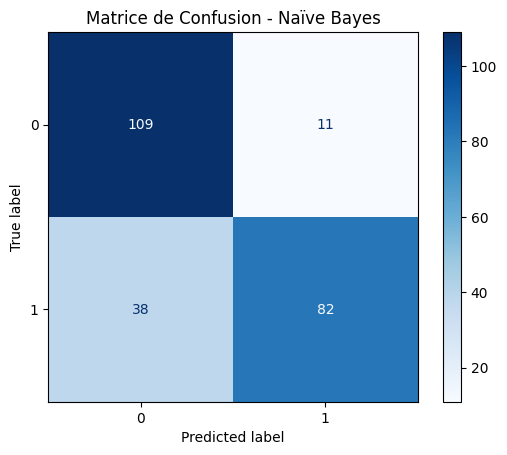


 Validation croisée pour le modèle : c-SVM
              precision    recall  f1-score   support

           0      0.812     0.900     0.854       120
           1      0.888     0.792     0.837       120

    accuracy                          0.846       240
   macro avg      0.850     0.846     0.845       240
weighted avg      0.850     0.846     0.845       240



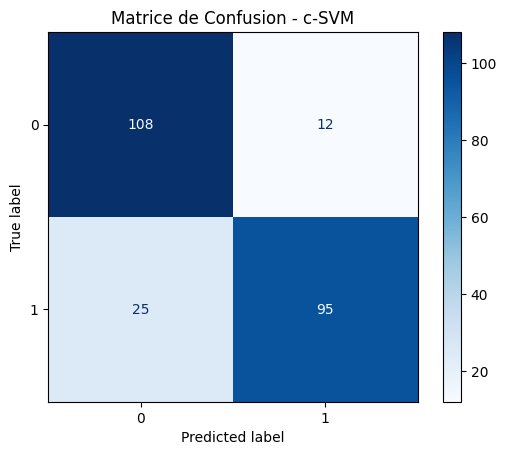


 Validation croisée pour le modèle : nu-SVM
              precision    recall  f1-score   support

           0      0.811     0.892     0.849       120
           1      0.880     0.792     0.833       120

    accuracy                          0.842       240
   macro avg      0.845     0.842     0.841       240
weighted avg      0.845     0.842     0.841       240



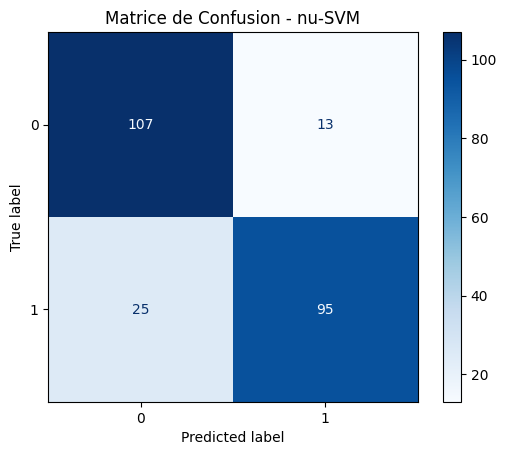


 Validation croisée pour le modèle : MLP
              precision    recall  f1-score   support

           0      0.776     0.808     0.792       120
           1      0.800     0.767     0.783       120

    accuracy                          0.787       240
   macro avg      0.788     0.788     0.787       240
weighted avg      0.788     0.787     0.787       240



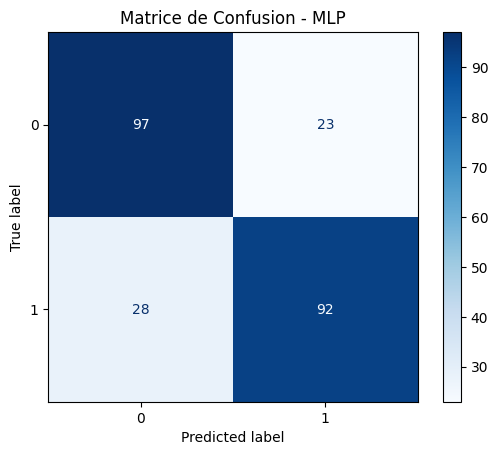


 Validation croisée pour le modèle : KNN
              precision    recall  f1-score   support

           0      0.786     0.825     0.805       120
           1      0.816     0.775     0.795       120

    accuracy                          0.800       240
   macro avg      0.801     0.800     0.800       240
weighted avg      0.801     0.800     0.800       240



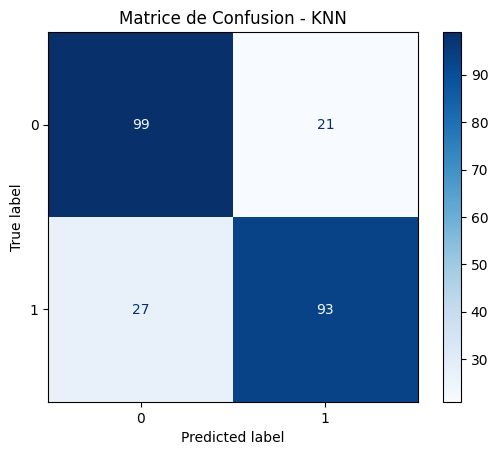


 Validation croisée pour le modèle : Random Forest
              precision    recall  f1-score   support

           0      0.785     0.850     0.816       120
           1      0.836     0.767     0.800       120

    accuracy                          0.808       240
   macro avg      0.810     0.808     0.808       240
weighted avg      0.810     0.808     0.808       240



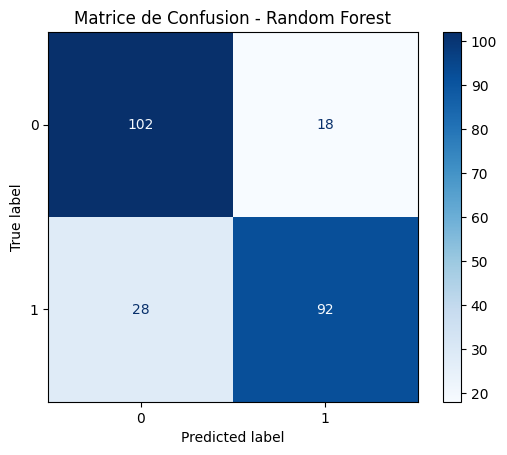


Résumé des performances (Validation croisée 10-fold):

           Model  Accuracy  Precision    Recall  F1-Score
0    Naïve Bayes  0.795833   0.881720  0.683333  0.769953
1          c-SVM  0.845833   0.887850  0.791667  0.837004
2         nu-SVM  0.841667   0.879630  0.791667  0.833333
3            MLP  0.787500   0.800000  0.766667  0.782979
4            KNN  0.800000   0.815789  0.775000  0.794872
5  Random Forest  0.808333   0.836364  0.766667  0.800000


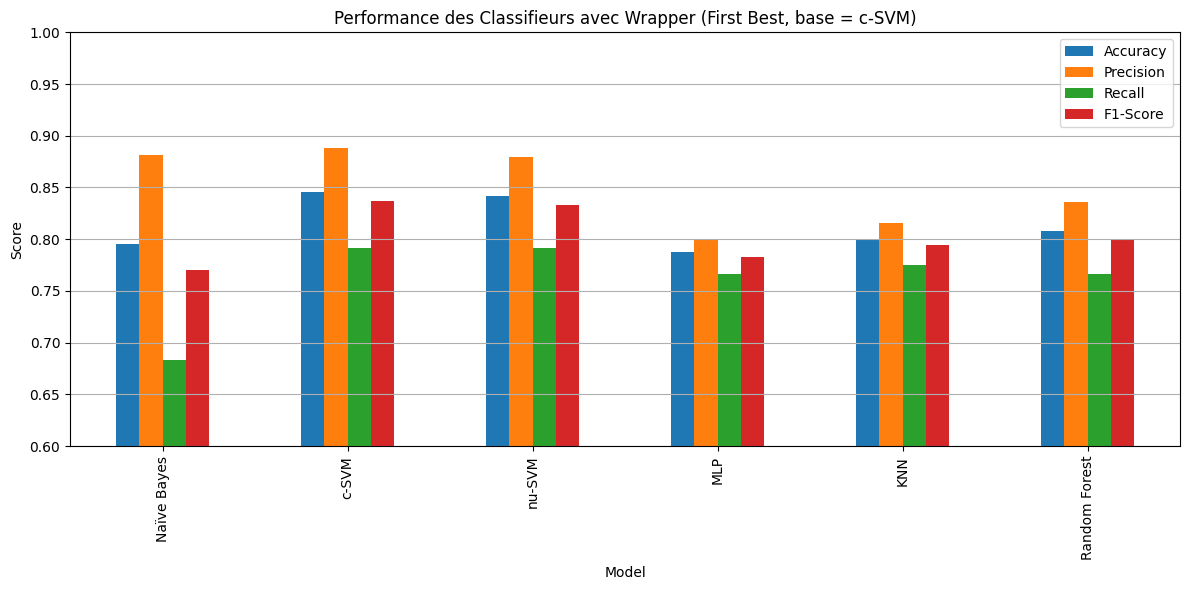

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Sélection de caractéristiques avec c-SVM comme base (First Best)
svm_base = SVC(kernel='rbf', C=1.0)
selector = SequentialFeatureSelector(
    estimator=svm_base,
    direction='forward',
    cv=5,
    n_jobs=-1
)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]
print(f"Nombre de caractéristiques sélectionnées : {len(selected_features)}")
print("Caractéristiques sélectionnées :", list(selected_features))

# 4. Classifieurs à évaluer
models = {
    'Naïve Bayes': GaussianNB(),
    'c-SVM': SVC(kernel='rbf'),
    'nu-SVM': NuSVC(nu=0.5, kernel='rbf'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5. Validation croisée 10-fold + Résultats détaillés
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    print(f"\n Validation croisée pour le modèle : {name}")
    y_pred = cross_val_predict(model, X_selected, y, cv=kf)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # Affichage du rapport de classification
    print(classification_report(y, y_pred, digits=3))

    # Affichage de la matrice de confusion
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_ if hasattr(model, 'classes_') else [0, 1])
    disp.plot(cmap='Blues')
    plt.title(f"Matrice de Confusion - {name}")
    plt.grid(False)
    plt.show()

# 6. Tableau final
results_df = pd.DataFrame(results)
print("\nRésumé des performances (Validation croisée 10-fold):\n")
print(results_df)

# 7. Courbe de performance
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs avec Wrapper (First Best, base = c-SVM)")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


greedy stepwise

Nombre de caractéristiques sélectionnées : 23
Caractéristiques sélectionnées : ['Shim_loc', 'Shim_dB', 'Shi_APQ11', 'HNR05', 'HNR35', 'RPDE', 'PPE', 'GNE', 'MFCC5', 'MFCC7', 'MFCC11', 'Delta0', 'Delta1', 'Delta3', 'Delta4', 'Delta5', 'Delta6', 'Delta7', 'Delta9', 'Delta10', 'Delta11', 'Delta12', 'Gender_1']

🔍 Validation croisée pour le modèle : Naïve Bayes
              precision    recall  f1-score   support

           0      0.820     0.833     0.826       120
           1      0.831     0.817     0.824       120

    accuracy                          0.825       240
   macro avg      0.825     0.825     0.825       240
weighted avg      0.825     0.825     0.825       240



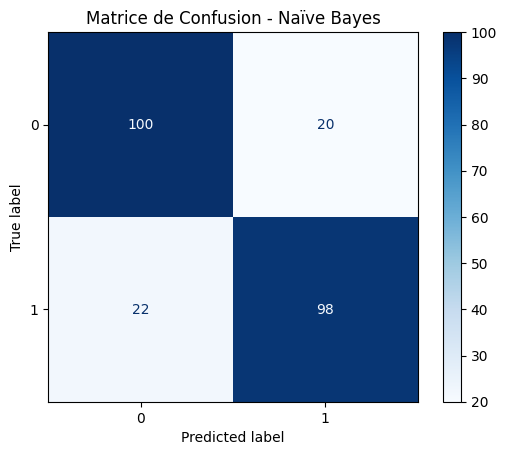


🔍 Validation croisée pour le modèle : c-SVM
              precision    recall  f1-score   support

           0      0.815     0.883     0.848       120
           1      0.873     0.800     0.835       120

    accuracy                          0.842       240
   macro avg      0.844     0.842     0.841       240
weighted avg      0.844     0.842     0.841       240



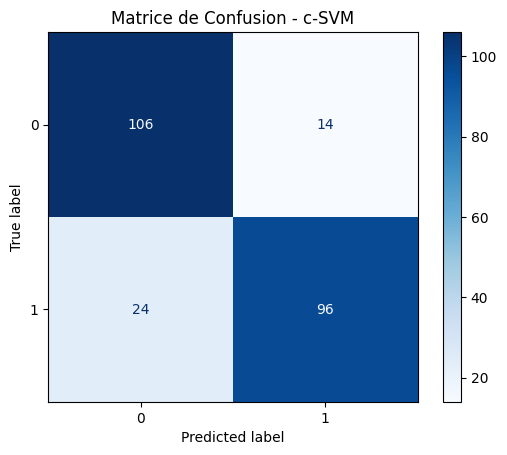


🔍 Validation croisée pour le modèle : nu-SVM
              precision    recall  f1-score   support

           0      0.824     0.858     0.841       120
           1      0.852     0.817     0.834       120

    accuracy                          0.838       240
   macro avg      0.838     0.837     0.837       240
weighted avg      0.838     0.838     0.837       240



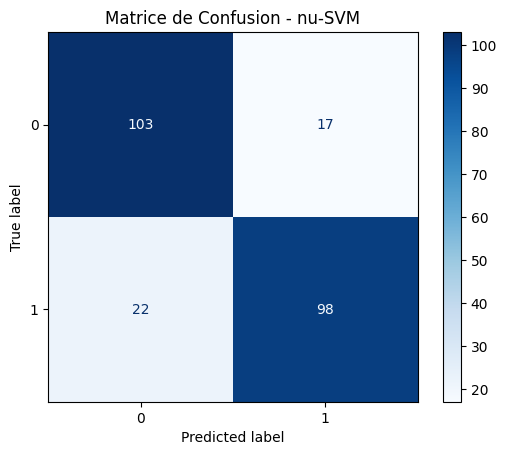


🔍 Validation croisée pour le modèle : MLP
              precision    recall  f1-score   support

           0      0.808     0.808     0.808       120
           1      0.808     0.808     0.808       120

    accuracy                          0.808       240
   macro avg      0.808     0.808     0.808       240
weighted avg      0.808     0.808     0.808       240



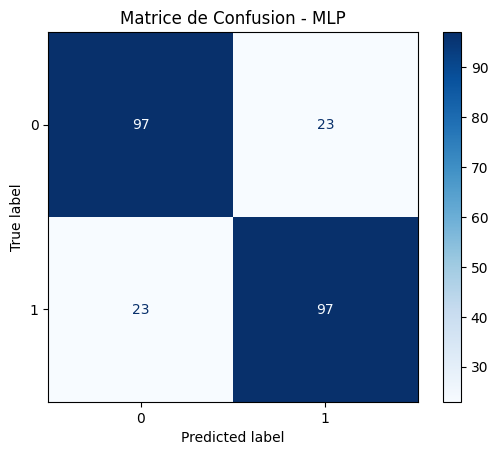


🔍 Validation croisée pour le modèle : KNN
              precision    recall  f1-score   support

           0      0.850     0.850     0.850       120
           1      0.850     0.850     0.850       120

    accuracy                          0.850       240
   macro avg      0.850     0.850     0.850       240
weighted avg      0.850     0.850     0.850       240



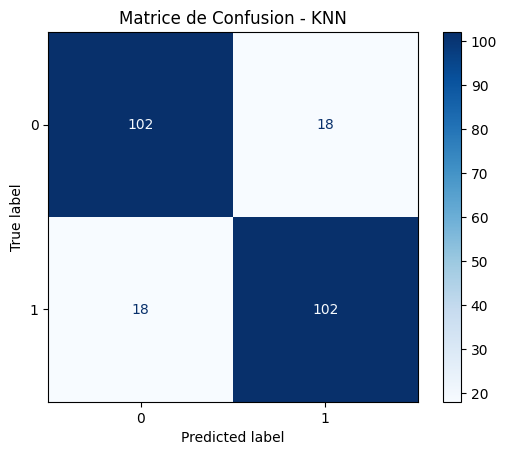


🔍 Validation croisée pour le modèle : Random Forest
              precision    recall  f1-score   support

           0      0.805     0.825     0.815       120
           1      0.821     0.800     0.810       120

    accuracy                          0.812       240
   macro avg      0.813     0.812     0.812       240
weighted avg      0.813     0.812     0.812       240



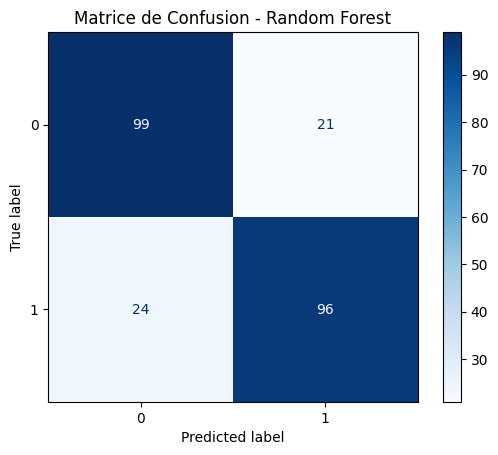


Résumé des performances (Validation croisée 10-fold):

           Model  Accuracy  Precision    Recall  F1-Score
0    Naïve Bayes  0.825000   0.830508  0.816667  0.823529
1          c-SVM  0.841667   0.872727  0.800000  0.834783
2         nu-SVM  0.837500   0.852174  0.816667  0.834043
3            MLP  0.808333   0.808333  0.808333  0.808333
4            KNN  0.850000   0.850000  0.850000  0.850000
5  Random Forest  0.812500   0.820513  0.800000  0.810127


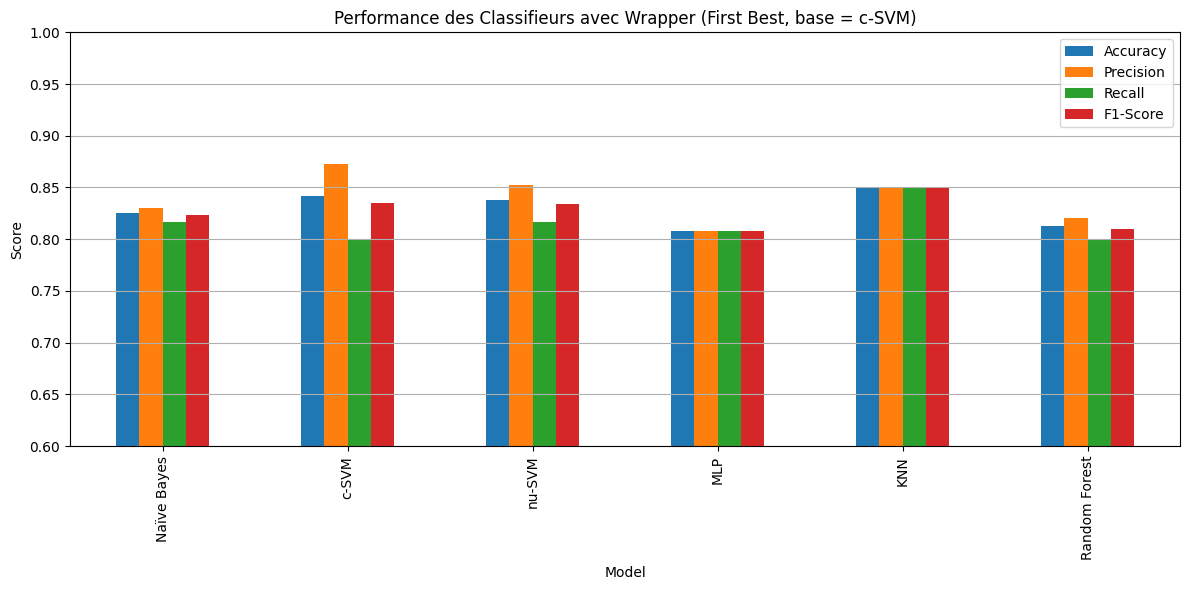

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Sélection de caractéristiques avec c-SVM comme base (First Best)
svm_base = SVC(kernel='rbf', C=1.0)
selector = SequentialFeatureSelector(
    estimator=svm_base,
    direction='backward',
    cv=5,
    n_jobs=-1
)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]
print(f"Nombre de caractéristiques sélectionnées : {len(selected_features)}")
print("Caractéristiques sélectionnées :", list(selected_features))

# 4. Classifieurs à évaluer
models = {
    'Naïve Bayes': GaussianNB(),
    'c-SVM': SVC(kernel='rbf'),
    'nu-SVM': NuSVC(nu=0.5, kernel='rbf'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5. Validation croisée 10-fold + Résultats détaillés
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    print(f"\n🔍 Validation croisée pour le modèle : {name}")
    y_pred = cross_val_predict(model, X_selected, y, cv=kf)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # Affichage du rapport de classification
    print(classification_report(y, y_pred, digits=3))

    # Affichage de la matrice de confusion
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_ if hasattr(model, 'classes_') else [0, 1])
    disp.plot(cmap='Blues')
    plt.title(f"Matrice de Confusion - {name}")
    plt.grid(False)
    plt.show()

# 6. Tableau final
results_df = pd.DataFrame(results)
print("\nRésumé des performances (Validation croisée 10-fold):\n")
print(results_df)

# 7. Courbe de performance
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs avec Wrapper (First Best, base = c-SVM)")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


PSO

2025-06-20 11:00:13,769 - pyswarms.discrete.binary - INFO - Optimize for 30 iters with {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 5, 'p': 2}
pyswarms.discrete.binary: 100%|██████████|30/30, best_cost=0.15 
2025-06-20 11:00:24,173 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.15000000000000002, best pos: [1 0 0 1 0 1 0 1 0 0 1 0 0 0 0 1 1 1 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 0 1 1 1
 0 1 0 0 0 1 1 1]



Nombre de caractéristiques sélectionnées : 26
Caractéristiques sélectionnées : ['Jitter_rel', 'Jitter_PPQ', 'Shim_dB', 'Shim_APQ5', 'HNR15', 'DFA', 'PPE', 'GNE', 'MFCC1', 'MFCC2', 'MFCC3', 'MFCC4', 'MFCC5', 'MFCC9', 'MFCC10', 'MFCC11', 'MFCC12', 'Delta0', 'Delta1', 'Delta3', 'Delta4', 'Delta5', 'Delta7', 'Delta11', 'Delta12', 'Gender_1']

 Validation croisée pour le modèle : Naïve Bayes
              precision    recall  f1-score   support

           0      0.805     0.825     0.815       120
           1      0.821     0.800     0.810       120

    accuracy                          0.812       240
   macro avg      0.813     0.812     0.812       240
weighted avg      0.813     0.812     0.812       240



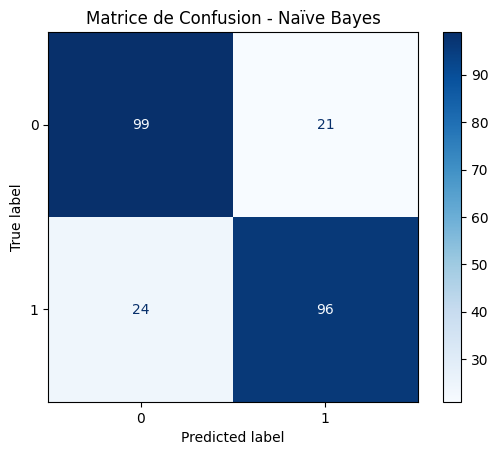


 Validation croisée pour le modèle : c-SVM
              precision    recall  f1-score   support

           0      0.831     0.858     0.844       120
           1      0.853     0.825     0.839       120

    accuracy                          0.842       240
   macro avg      0.842     0.842     0.842       240
weighted avg      0.842     0.842     0.842       240



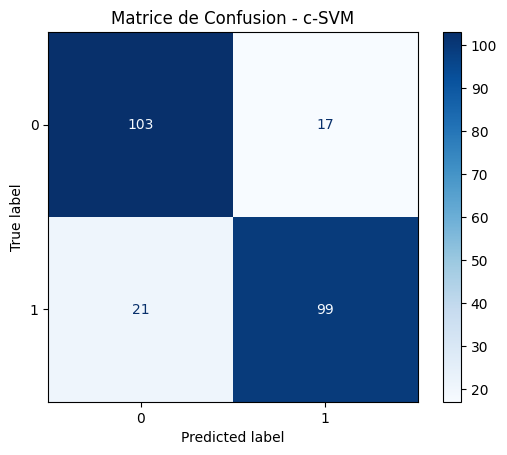


 Validation croisée pour le modèle : nu-SVM
              precision    recall  f1-score   support

           0      0.835     0.842     0.838       120
           1      0.840     0.833     0.837       120

    accuracy                          0.838       240
   macro avg      0.838     0.838     0.837       240
weighted avg      0.838     0.838     0.837       240



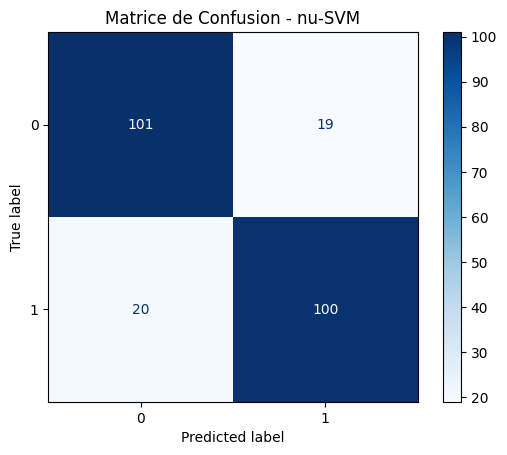


 Validation croisée pour le modèle : MLP
              precision    recall  f1-score   support

           0      0.774     0.800     0.787       120
           1      0.793     0.767     0.780       120

    accuracy                          0.783       240
   macro avg      0.784     0.783     0.783       240
weighted avg      0.784     0.783     0.783       240



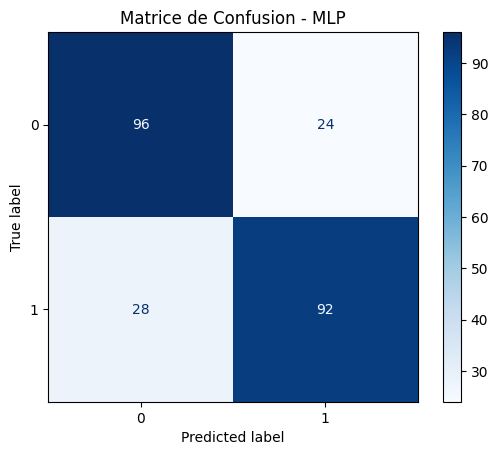


 Validation croisée pour le modèle : KNN
              precision    recall  f1-score   support

           0      0.821     0.842     0.831       120
           1      0.838     0.817     0.827       120

    accuracy                          0.829       240
   macro avg      0.829     0.829     0.829       240
weighted avg      0.829     0.829     0.829       240



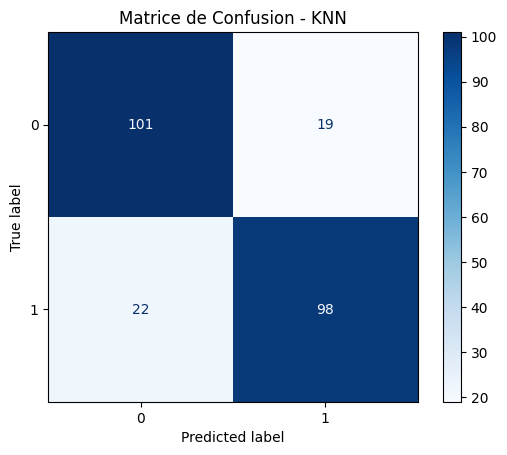


 Validation croisée pour le modèle : Random Forest
              precision    recall  f1-score   support

           0      0.792     0.825     0.808       120
           1      0.817     0.783     0.800       120

    accuracy                          0.804       240
   macro avg      0.805     0.804     0.804       240
weighted avg      0.805     0.804     0.804       240



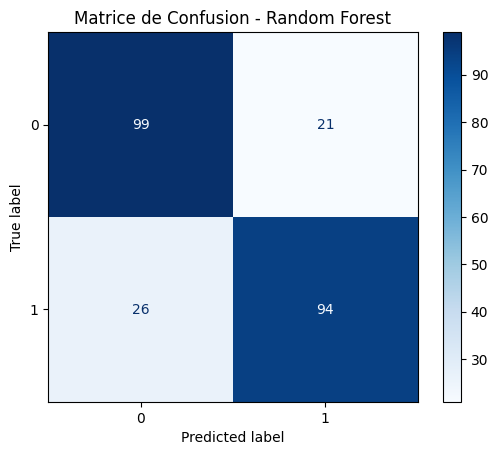


Résumé des performances (PSO avec c-SVM pour sélection des features):

           Model  Accuracy  Precision    Recall  F1-Score
0    Naïve Bayes  0.812500   0.820513  0.800000  0.810127
1          c-SVM  0.841667   0.853448  0.825000  0.838983
2         nu-SVM  0.837500   0.840336  0.833333  0.836820
3            MLP  0.783333   0.793103  0.766667  0.779661
4            KNN  0.829167   0.837607  0.816667  0.827004
5  Random Forest  0.804167   0.817391  0.783333  0.800000


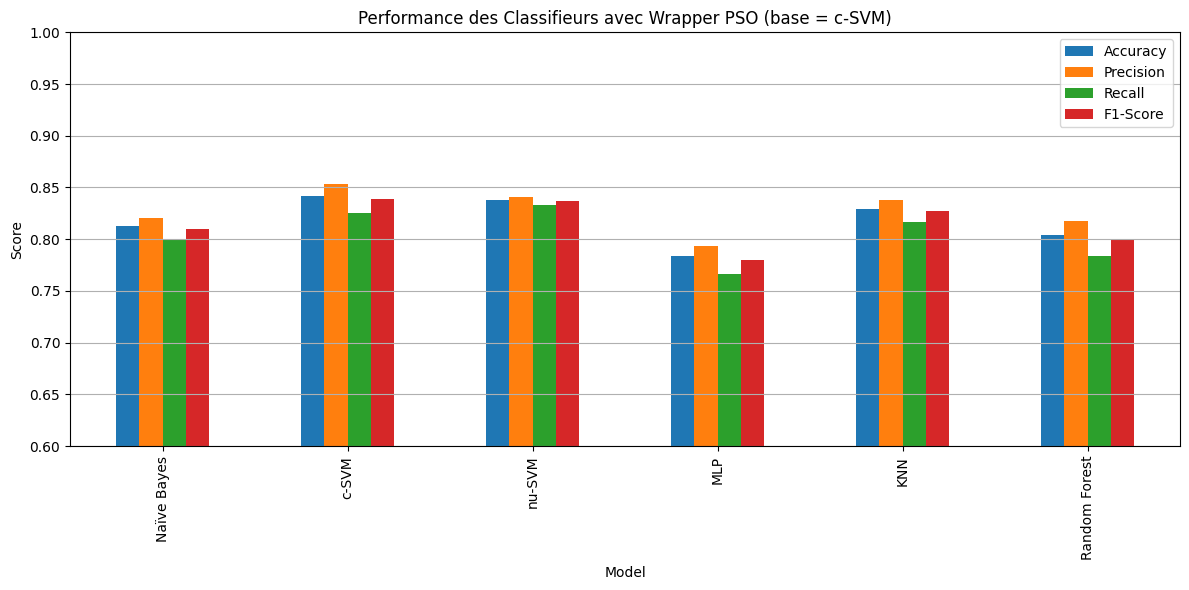

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, NuSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pyswarms as ps

# 1. Chargement des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Fonction d’évaluation pour PSO avec c-SVM
def fitness_function(particles):
    scores = []
    for particle in particles:
        mask = particle > 0.5
        if np.sum(mask) == 0:
            scores.append(1.0)
            continue
        X_sub = X_scaled[:, mask]
        score = cross_val_score(SVC(kernel='rbf', C=1.0), X_sub, y, cv=5, scoring='accuracy').mean()
        scores.append(1 - score)  # minimisation
    return np.array(scores)

# 4. Paramètres PSO
n_particles = 20
dimensions = X_scaled.shape[1]
options = {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 5, 'p': 2}

# 5. Optimisation PSO
optimizer = ps.discrete.BinaryPSO(n_particles=n_particles, dimensions=dimensions, options=options)
best_cost, best_pos = optimizer.optimize(fitness_function, iters=30, verbose=True)

# 6. Sélection des meilleures caractéristiques
selected_mask = best_pos > 0.5
X_selected = X_scaled[:, selected_mask]
selected_features = X.columns[selected_mask]
print(f"\nNombre de caractéristiques sélectionnées : {np.sum(selected_mask)}")
print("Caractéristiques sélectionnées :", list(selected_features))

# 7. Modèles à évaluer
models = {
    'Naïve Bayes': GaussianNB(),
    'c-SVM': SVC(kernel='rbf'),
    'nu-SVM': NuSVC(nu=0.5, kernel='rbf'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 8. Évaluation croisée 10-fold
results = []
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\n Validation croisée pour le modèle : {name}")
    y_pred = cross_val_predict(model, X_selected, y, cv=kf)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(classification_report(y, y_pred, digits=3))
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues')
    plt.title(f"Matrice de Confusion - {name}")
    plt.grid(False)
    plt.show()

# 9. Tableau des performances
results_df = pd.DataFrame(results)
print("\nRésumé des performances (PSO avec c-SVM pour sélection des features):\n")
print(results_df)

# 10. Graphe comparatif
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs avec Wrapper PSO (base = c-SVM)")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
